# 01 · Blending two guesses

**The idea in one sentence:** when you have two uncertain guesses about the same
thing, the best combined guess leans toward whichever one you trust more — and the
combined guess is *more certain than either one alone*.

That is the whole of the Kalman filter's update step. Everything else in this series
(attendance, hidden states, ensembles) is this idea applied repeatedly.

### The toy problem

A parcel sits on a cheap kitchen scale. Its true weight never changes, but every
reading is off by a random amount. Before we weigh it we already have a rough idea
("the label says about 2.0 kg, give or take"). We want to:

1. combine that rough idea with one reading,
2. then keep folding in more readings, one at a time,
3. and watch our uncertainty shrink as we go.

### Vocabulary

| Symbol | Meaning in this notebook |
| --- | --- |
| `x` | our current best guess of the weight |
| `P` | the **variance** of that guess (standard deviation squared) — how unsure we are |
| `z` | one scale reading (a *measurement*) |
| `R` | the variance of the scale's noise — how unsure we are about each reading |
| `K` | the **Kalman gain**, between 0 and 1: how far we move toward the reading |

We use variances rather than standard deviations because variances add up neatly.
No attendance data appears in this notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from nowcast.kalman import predict, update, run_filter, kalman_gain
from nowcast.style import COLORS, apply_style

apply_style()
rng = np.random.default_rng(seed=1)   # fixed seed so the notebook is reproducible

## 1. One blend, done by hand

Our **prior** (the guess before measuring): 2.0 kg with a standard deviation of
0.2 kg, so `P = 0.2² = 0.04`.

The scale reads **2.3 kg**, and we know from the manual that it is good to about
±0.1 kg (one standard deviation), so `R = 0.1² = 0.01`.

The scale is the more trustworthy of the two (smaller variance), so the answer
should land closer to 2.3 than to 2.0. The three update equations:

$$K = \frac{P}{P + R}$$

*"What share of the total uncertainty belongs to my prior?"* If the prior holds most
of the uncertainty, K is close to 1 and we trust the reading.

$$x_{\text{new}} = x + K\,(z - x)$$

*"Start at my prior and move a fraction K of the way toward the reading."*
The quantity `z − x` is called the **innovation**: how surprised we are.

$$P_{\text{new}} = (1 - K)\,P$$

*"My uncertainty shrinks by the same fraction I moved."* Because 0 ≤ K ≤ 1, the new
variance can never be larger than the old one.

In [2]:
x_prior, P_prior = 2.0, 0.2**2     # prior guess and its variance
z, R = 2.3, 0.1**2                 # scale reading and its noise variance

# Written out by hand, one line per equation:
K = P_prior / (P_prior + R)
x_post = x_prior + K * (z - x_prior)
P_post = (1 - K) * P_prior

print(f"gain K           = {K:.2f}   (we move {K:.0%} of the way to the reading)")
print(f"posterior x      = {x_post:.3f} kg")
print(f"posterior std    = {np.sqrt(P_post):.3f} kg  (prior was 0.200, scale was 0.100)")

# The library function gives the same numbers:
x_lib, P_lib, K_lib = update(x_prior, P_prior, z, R)
print(f"nowcast.kalman.update -> x = {x_lib:.3f}, P = {P_lib:.4f}, K = {K_lib:.2f}")

gain K           = 0.80   (we move 80% of the way to the reading)
posterior x      = 2.240 kg
posterior std    = 0.089 kg  (prior was 0.200, scale was 0.100)
nowcast.kalman.update -> x = 2.240, P = 0.0080, K = 0.80


Two things to notice:

* **The estimate is a weighted average.** K = 0.8 means 80% weight on the reading,
  20% on the prior — exactly the ratio of their variances (0.04 : 0.01 → 4 : 1).
* **The combined standard deviation (≈0.089 kg) is smaller than the scale's (0.1 kg).**
  Even a poor prior adds information. That is why blending beats picking the
  "best" single source.

A picture of the same blend: each guess is a bell curve; the blend is narrower
than both and sits between them, closer to the narrower one.

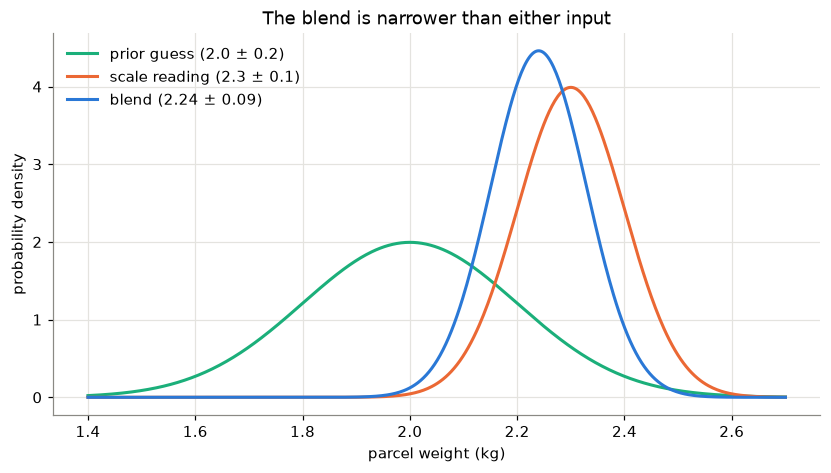

In [3]:
def bell(mean, var, grid):
    # Normal probability density, written out so nothing is hidden.
    return np.exp(-(grid - mean) ** 2 / (2 * var)) / np.sqrt(2 * np.pi * var)

grid = np.linspace(1.4, 2.7, 500)
fig, ax = plt.subplots()
ax.plot(grid, bell(x_prior, P_prior, grid), color=COLORS["forecast"], label="prior guess (2.0 ± 0.2)")
ax.plot(grid, bell(z, R, grid), color=COLORS["measurement"], label="scale reading (2.3 ± 0.1)")
ax.plot(grid, bell(x_post, P_post, grid), color=COLORS["estimate"], label=f"blend ({x_post:.2f} ± {np.sqrt(P_post):.2f})")
ax.set_xlabel("parcel weight (kg)")
ax.set_ylabel("probability density")
ax.set_title("The blend is narrower than either input")
ax.legend(loc="upper left")
plt.show()

## 2. How the gain depends on the two variances

The gain only depends on the **ratio** of prior variance to measurement variance.
Below, the prior variance is fixed and we sweep the measurement noise `R`:

* `R` tiny (perfect scale) → K → 1 → we copy the reading.
* `R` huge (useless scale) → K → 0 → we keep the prior.
* `R = P` → K = 0.5 → a plain average.

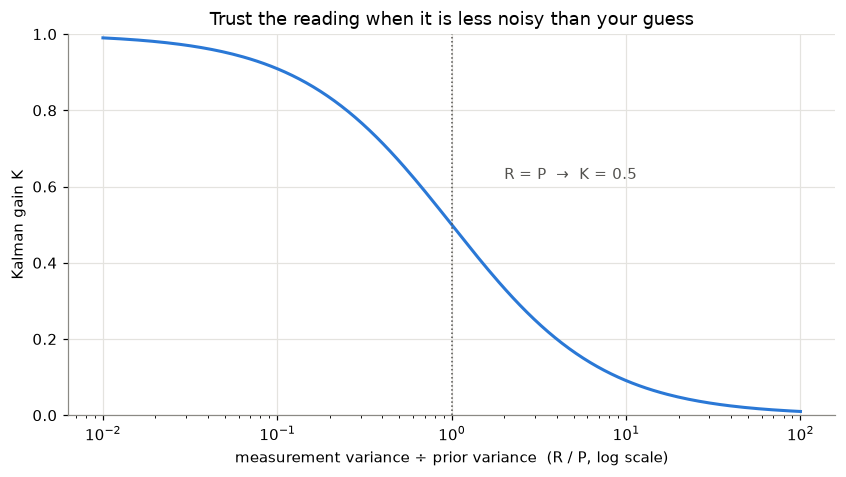

In [4]:
P_fixed = 1.0
ratios = np.logspace(-2, 2, 200)          # R / P from 0.01 to 100
gains = [kalman_gain(P_fixed, r * P_fixed) for r in ratios]

fig, ax = plt.subplots()
ax.plot(ratios, gains, color=COLORS["estimate"])
ax.axvline(1.0, color=COLORS["muted"], lw=1, ls=":")
ax.annotate("R = P  →  K = 0.5", xy=(1.0, 0.5), xytext=(2.0, 0.62), color=COLORS["muted"])
ax.set_xscale("log")
ax.set_ylim(0, 1)
ax.set_xlabel("measurement variance ÷ prior variance  (R / P, log scale)")
ax.set_ylabel("Kalman gain K")
ax.set_title("Trust the reading when it is less noisy than your guess")
plt.show()

## 3. Many readings, one at a time

Now we weigh the parcel 15 times. Its true weight is 2.17 kg (the filter never sees
this; we only use it for checking). Each reading has noise with standard deviation
0.1 kg.

The loop below is the full Kalman filter for a constant quantity. Each pass has
two steps:

1. **Predict:** `x⁻ = x`, `P⁻ = P + Q`. Time passes; the weight doesn't change, so the
   guess stays put. `Q` (process noise) lets us say "the true value might have
   drifted a little". A parcel doesn't drift, so here `Q = 0`.
2. **Update:** the three equations from Section 1, with `x⁻` and `P⁻` as the prior.

After each update the posterior becomes the next step's prior. That is the only
new idea: **yesterday's answer is today's prior.**

In [5]:
true_weight = 2.17
n_readings = 15
R_scale = 0.1**2
readings = true_weight + rng.normal(0.0, np.sqrt(R_scale), size=n_readings)

x, P, Q = 2.0, 0.2**2, 0.0           # start from the same prior as before
history = []                         # (x, P, K) after each reading
for z in readings:
    x, P = predict(x, P, Q)          # step 1: predict
    x, P, K = update(x, P, z, R_scale)  # step 2: update
    history.append((x, P, K))

xs = np.array([h[0] for h in history])
Ps = np.array([h[1] for h in history])
Ks = np.array([h[2] for h in history])

print(" n   reading   gain K   estimate   std")
for i in range(n_readings):
    print(f"{i+1:2d}   {readings[i]:.3f}    {Ks[i]:.3f}    {xs[i]:.3f}     {np.sqrt(Ps[i]):.3f}")

 n   reading   gain K   estimate   std
 1   2.205    0.800    2.164     0.089
 2   2.252    0.444    2.203     0.067
 3   2.203    0.308    2.203     0.055
 4   2.040    0.235    2.165     0.049
 5   2.261    0.190    2.183     0.044
 6   2.215    0.160    2.188     0.040
 7   2.116    0.138    2.178     0.037
 8   2.228    0.121    2.184     0.035
 9   2.206    0.108    2.187     0.033
10   2.199    0.098    2.188     0.031
11   2.173    0.089    2.186     0.030
12   2.225    0.082    2.190     0.029
13   2.096    0.075    2.183     0.027
14   2.154    0.070    2.181     0.026
15   2.122    0.066    2.177     0.026


Read down the **gain** column: it starts high (the first reading is much better than
our rough prior) and then falls. After many readings our estimate is already good,
so each new noisy reading can only nudge it. Note that the gain does not depend on
the readings at all — only on the variances. You could compute the whole gain
column before the first weighing.

The chart shows the estimate with a shaded **±2σ band** (σ = √P). Roughly 95% of
the time the truth should sit inside it.

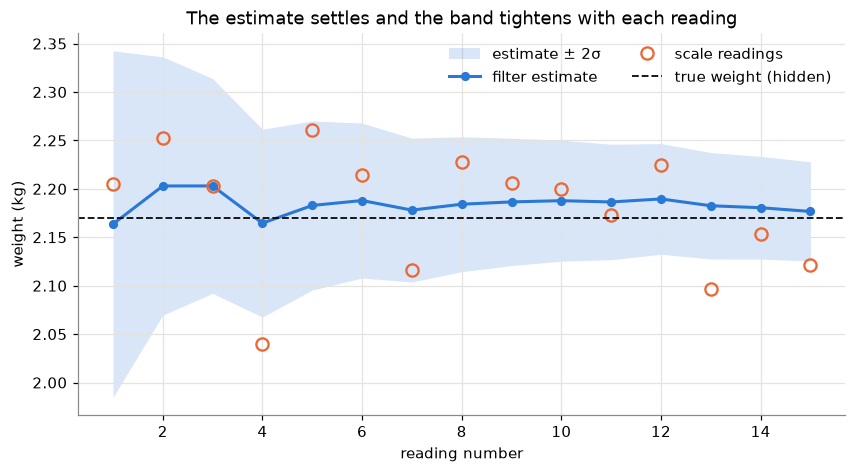

In [6]:
steps = np.arange(1, n_readings + 1)
sigma = np.sqrt(Ps)

fig, ax = plt.subplots()
ax.fill_between(steps, xs - 2 * sigma, xs + 2 * sigma, color=COLORS["estimate"], alpha=0.18, lw=0,
                label="estimate ± 2σ")
ax.plot(steps, xs, color=COLORS["estimate"], marker="o", label="filter estimate")
ax.plot(steps, readings, ls="none", marker="o", mfc="none", mew=1.5, ms=8,
        color=COLORS["measurement"], label="scale readings")
ax.axhline(true_weight, color=COLORS["truth"], ls="--", lw=1.2, label="true weight (hidden)")
ax.set_xlabel("reading number")
ax.set_ylabel("weight (kg)")
ax.set_title("The estimate settles and the band tightens with each reading")
ax.legend(loc="upper right", ncol=2)
plt.show()

## 4. How fast does the variance shrink?

With `Q = 0` there is a closed form. After `n` readings of equal noise `R`, starting
from prior variance `P₀`:

$$P_n = \frac{P_0\,R}{R + n\,P_0}$$

In plain English: once `n·P₀` is much bigger than `R`, this is about `R / n`, the
familiar "averaging `n` readings divides the variance by `n`". A Kalman filter with
a constant state and no process noise *is* a running weighted average.

The check below compares the loop's `P` with the formula.

max |loop − formula| = 1.734723475976807e-18


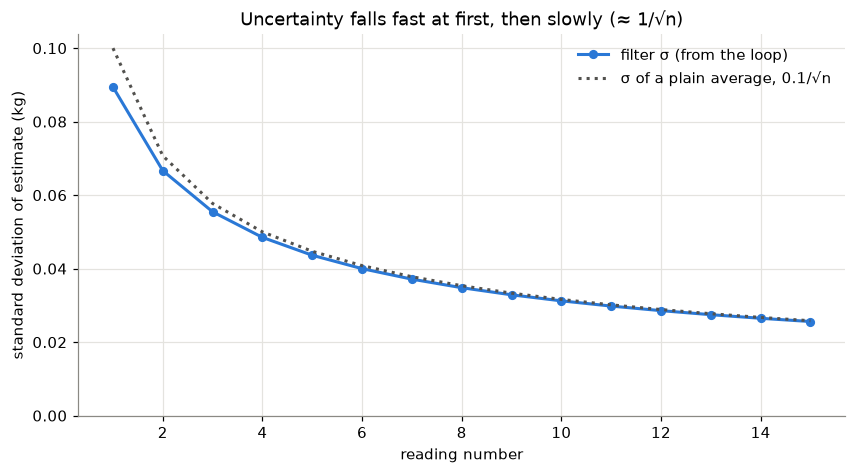

In [7]:
P0 = 0.2**2
closed_form = P0 * R_scale / (R_scale + steps * P0)
print("max |loop − formula| =", np.max(np.abs(Ps - closed_form)))

fig, ax = plt.subplots()
ax.plot(steps, np.sqrt(Ps), color=COLORS["estimate"], marker="o", label="filter σ (from the loop)")
ax.plot(steps, np.sqrt(R_scale / steps), color=COLORS["muted"], ls=":", label="σ of a plain average, 0.1/√n")
ax.set_xlabel("reading number")
ax.set_ylabel("standard deviation of estimate (kg)")
ax.set_ylim(0, None)
ax.set_title("Uncertainty falls fast at first, then slowly (≈ 1/√n)")
ax.legend()
plt.show()

The filter line sits just below the plain-average line: the prior counts as a little
bit of extra evidence, worth about `R / P₀ = 0.25` of a reading.

## 5. The two extremes, and what `Q` does

Two sanity checks that the automated tests also enforce:

* With a **huge `R`**, readings are ignored and the estimate stays at the prior.
* With a **tiny `R`**, the first update snaps to the reading.

Watch the second case closely: after that first snap, `P` is tiny as well, so the
*ratio* `R / P` is back near 1 and later readings get averaged instead of copied.
The gain depends on the ratio of the two variances, never on either one alone.

Then one new knob: **process noise `Q`**. Adding `Q` at every predict step says
"the truth might move between readings". The variance then stops shrinking toward
zero and levels off, so the filter always keeps listening to new data. In the
attendance notebooks `Q` covers surprises like a sudden storm.

huge R: final estimate 2.000   (prior was 2.000)
tiny R: estimate after reading 1 = 2.2046   (reading 1 was 2.2046)
        gain at readings 1, 2, 3 = [1.    0.5   0.333]


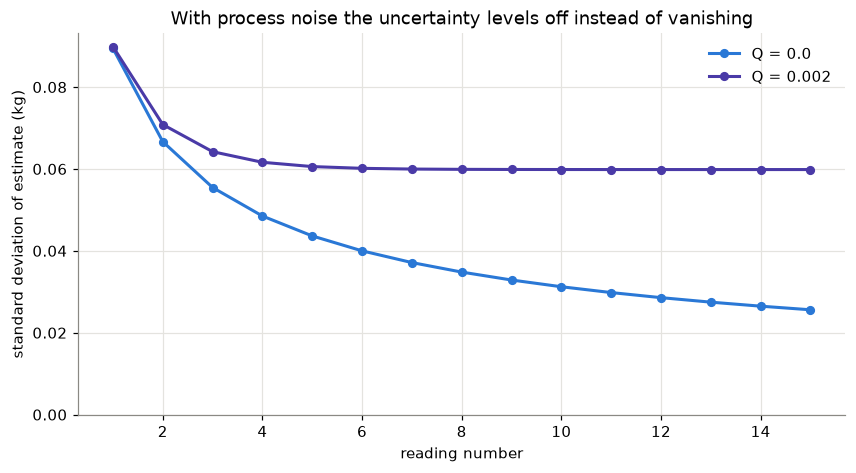

In [8]:
out = run_filter(2.0, P0, readings, Rs=1e6, Q=0.0)
print(f"huge R: final estimate {out['x'][-1]:.3f}   (prior was 2.000)")

out = run_filter(2.0, P0, readings, Rs=1e-8, Q=0.0)
print(f"tiny R: estimate after reading 1 = {out['x'][0]:.4f}   (reading 1 was {readings[0]:.4f})")
print(f"        gain at readings 1, 2, 3 = {np.round(out['K'][:3], 3)}")

fig, ax = plt.subplots()
for Q_val, color in [(0.0, COLORS["estimate"]), (0.002, COLORS["alt"])]:
    out = run_filter(2.0, P0, readings, Rs=R_scale, Q=Q_val)
    ax.plot(steps, np.sqrt(out["P"]), color=color, marker="o", label=f"Q = {Q_val}")
ax.set_xlabel("reading number")
ax.set_ylabel("standard deviation of estimate (kg)")
ax.set_ylim(0, None)
ax.set_title("With process noise the uncertainty levels off instead of vanishing")
ax.legend()
plt.show()

## Summary

* **Update = weighted average.** `K = P / (P + R)` sets the weights from the two
  variances; the estimate moves a fraction `K` toward the measurement.
* **Blending always helps.** The posterior variance `(1 − K)P` is never larger than
  the prior variance, and it is smaller than the measurement's variance too.
* **Repeat it.** The posterior becomes the next prior. With `Q = 0` the variance
  falls like `1/n`; with `Q > 0` it levels off, so the filter keeps adapting.
* **The gain comes from the variances, not the data.** Getting `P`, `R` and `Q`
  right is the real modelling work.

**Next, notebook 02:** the "parcel weight" becomes *today's final attendance*, the
prior becomes the pre-open forecast, and each hour's gate count becomes a reading
whose noise `R_t` changes through the day.